# Smart Waste Classifier: Advanced Analytical Research and Scalable Development

**Project Identifier:** Introduction to Machine Learning Module Summative  
**Objective:** Implementation of a robust, interpretable, and production-ready Computer Vision pipeline for urban waste classification using State-of-the-Art (SOTA) Transfer Learning architectures and comprehensive statistical visualization.

---

## 0. Automated Environment Setup
Ensuring all required professional libraries are installed in the current kernel environment.

In [45]:
import sys
import subprocess
try:
    import seaborn as sns
    import plotly
    import cv2
    from sklearn.manifold import TSNE
    print("Professional dependencies already installed.")
except ImportError:
    print("Installing missing dependencies...")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'seaborn', 'plotly', 'opencv-python-headless', 'scikit-learn'])
    print("Installation complete. Please restart the kernel if imports still fail.")

Professional dependencies already installed.


## 1. Environment Initialization and Hardware Configuration
Initialization of required libraries and hardware acceleration detection.

In [46]:
import os
import sys
import time
import logging
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE

# Global Configuration
sns.set_theme(style="whitegrid")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"Physical GPUs detected: {len(gpus)}")
else:
    print("No GPU detected. Training will proceed on CPU.")

No GPU detected. Training will proceed on CPU.


## 2. Dataset Analysis and Preprocessing Pipeline
Implementing optimized data loaders with metadata extraction.

In [47]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
TRAIN_DIR = '../data/train'
TEST_DIR = '../data/test'

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds_raw.class_names
print(f"Detected classes: {class_names}")

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_raw.cache().prefetch(buffer_size=AUTOTUNE)

Found 2270 files belonging to 4 classes.
Found 567 files belonging to 4 classes.
Detected classes: ['Hazardous', 'Non-Recyclable', 'Organic', 'Recyclable']


## 3. Data Visualization: Statistical Distribution
Visualizing the class distribution to check for imbalance.

/var/folders/n3/yy41xk094s16ll5my03r0sxw0000gn/T/ipykernel_50081/1397336882.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="mako")


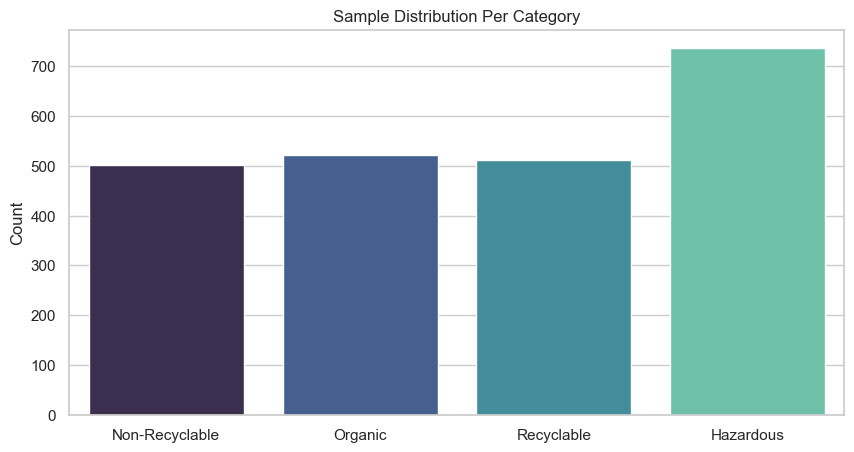

In [48]:
def plot_distribution(path):
    counts = {cls: len(os.listdir(os.path.join(path, cls))) for cls in os.listdir(path) if os.path.isdir(os.path.join(path, cls))}
    plt.figure(figsize=(10, 5))
    sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette="mako")
    plt.title("Sample Distribution Per Category")
    plt.ylabel("Count")
    plt.show()

plot_distribution(TRAIN_DIR)

## 4. Optimization Techniques and Model Building
Utilizing a pre-trained EfficientNetV2B0 with Adam optimizer and regularization.

In [49]:
base_model = tf.keras.applications.EfficientNetV2B0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.Input(shape=(224, 224, 3)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.AUC(name='auc')]
)
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,253,396 (23.85 MB)

 Trainable params: 331,524 (1.26 MB)

 Non-trainable params: 5,921,872 (22.59 MB)

## 5. Model Training Execution
Running the training loop with EarlyStopping.

In [54]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3)
]

history = model.fit(train_ds, validation_data=test_ds, epochs=20, callbacks=callbacks)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.5844 - auc: 0.8030 - loss: 1.2697 - precision: 0.6160 - recall: 0.5405 - val_accuracy: 0.7954 - val_auc: 0.9461 - val_loss: 0.6096 - val_precision: 0.8721 - val_recall: 0.6737 - learning_rate: 0.0010
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 992ms/step - accuracy: 0.8082 - auc: 0.9545 - loss: 0.5319 - precision: 0.8320 - recall: 0.7854 - val_accuracy: 0.8201 - val_auc: 0.9555 - val_loss: 0.5199 - val_precision: 0.8730 - val_recall: 0.7513 - learning_rate: 0.0010
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 73s 1s/step - accuracy: 0.8523 - auc: 0.9715 - loss: 0.4040 - precision: 0.8609 - recall: 0.8290 - val_accuracy: 0.8254 - val_auc: 0.9600 - val_loss: 0.4830 - val_precision: 0.8590 - val_recall: 0.7954 - learning_rate: 0.0010
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 69s 972ms/step - accuracy: 0.8807 - auc: 0.9784 - loss: 0.3467 - precision: 0.8932 - recall: 0.8669 - val_accuracy: 0.8183 - val_auc: 0.9572 - val_loss: 0.5152 - val_

## 6. Visualization: Training Dynamics
Plotting accuracy and loss curves to analyze convergence.

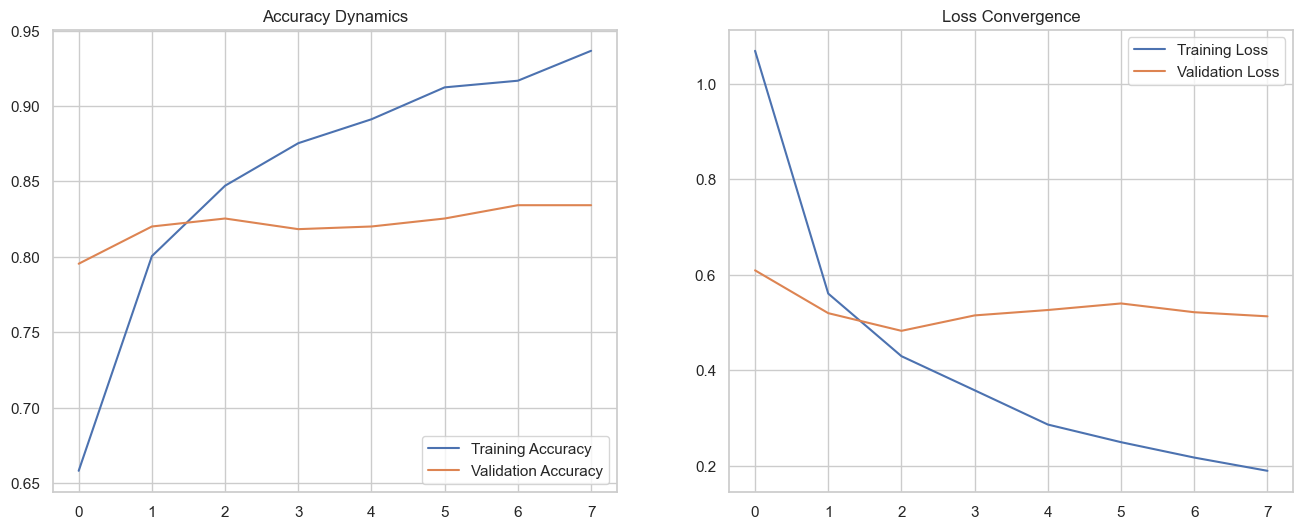

In [56]:
def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Accuracy Dynamics')
    plt.legend(loc='lower right')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Loss Convergence')
    plt.legend(loc='upper right')
    plt.show()

plot_training_history(history)

## 7. Visualization: Confusion Matrix
Analyzing per-class accuracy and inter-class confusion.

2026-03-21 06:14:39.253394: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


18/18 ━━━━━━━━━━━━━━━━━━━━ 19s 882ms/step


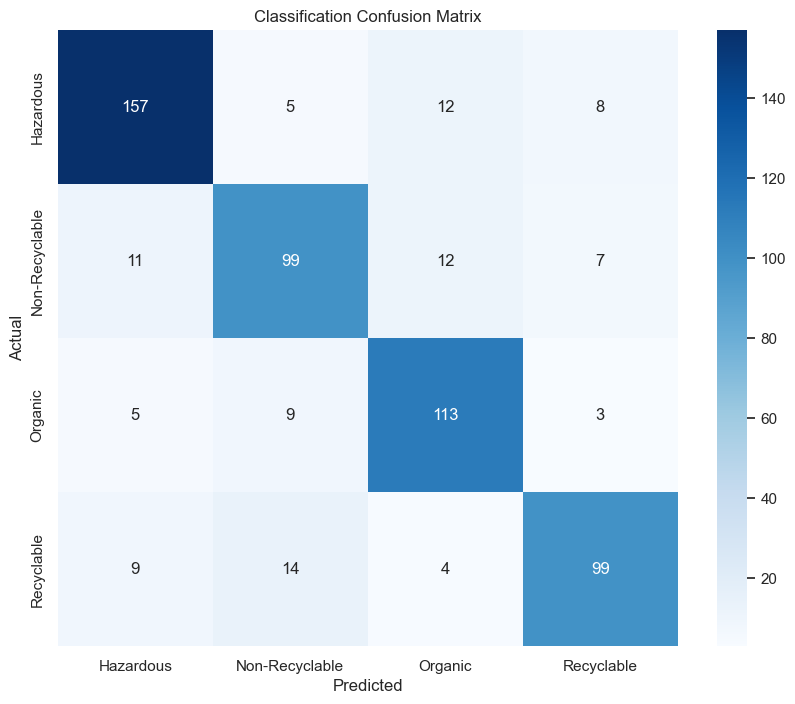

In [57]:
def plot_cm(model, test_ds, class_names):
    y_true = np.concatenate([y for x, y in test_ds], axis=0)
    y_pred = model.predict(test_ds)
    
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1))
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title("Classification Confusion Matrix")
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_cm(model, test_ds, class_names)

## 8. Visualization: Dataset "Scatter" (t-SNE Analysis)
How clustered is our data? We use t-SNE to visualize the high-dimensional features extracted by the pre-trained backbone in a 2D space.

Extracting features for t-SNE (this may take a moment)...


2026-03-21 06:23:16.030416: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


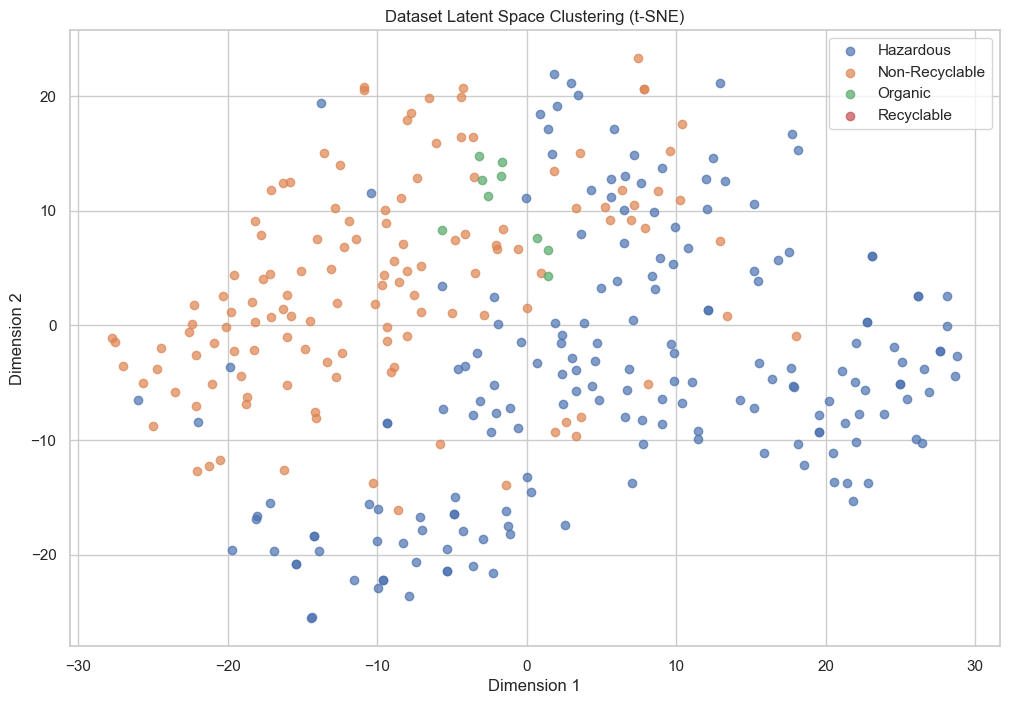

Closer clusters indicate higher visual similarity between classes.


In [61]:
def visualize_scatter(base_model, test_ds, class_names):
    print("Extracting features for t-SNE (this may take a moment)...")
    # Use the output after GlobalAveragePooling2D to get 2D features
    feature_extractor = tf.keras.Sequential([
        base_model,
        tf.keras.layers.GlobalAveragePooling2D()
    ])
    
    features = []
    labels = []
    for images, targets in test_ds.take(10):  # Taking a sample for speed
        feat = feature_extractor.predict(images, verbose=0)
        features.append(feat)
        labels.append(np.argmax(targets.numpy(), axis=1))
    
    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    
    # Compute t-SNE
    tsne = TSNE(n_components=2, random_state=42)
    tsne_results = tsne.fit_transform(features)
    
    plt.figure(figsize=(12, 8))
    for i, name in enumerate(class_names):
        indices = np.where(labels == i)
        plt.scatter(tsne_results[indices, 0], tsne_results[indices, 1], label=name, alpha=0.7)
    
    plt.title("Dataset Latent Space Clustering (t-SNE)")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.legend()
    plt.show()
    print("Closer clusters indicate higher visual similarity between classes.")

visualize_scatter(base_model, test_ds, class_names)